In [77]:
%pip install factor_analyzer
%pip install pingouin


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import pyreadstat
import matplotlib.pyplot as plt
import pingouin as pg
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.decomposition import FactorAnalysis
from factor_analyzer import FactorAnalyzer
from pandas import Series
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer import calculate_kmo
from pathlib import Path



In [46]:
df, meta = pyreadstat.read_sav('BD_MI_II_2024_25.sav')
# uncomment to see the entire table
#with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.precision', 3):
#    display(df)

df.head()


,id,idade,nacional,nacional_other,hab,gender,gender_other,rendim,IES,IES_outra,...,QVA_4,QVA_5,QVA_6,QVA_7,QVA_8,QVA_9,QVA_10,QVA_11,QVA_12,QVA_13
0,619.0,23.0,1.0,,3.0,1.0,,4.0,1.0,,...,5.0,5.0,3.0,5.0,4.0,5.0,5.0,3.0,3.0,4.0
1,438.0,23.0,1.0,,5.0,2.0,,4.0,666666.0,Já não frequento,...,5.0,5.0,1.0,5.0,4.0,4.0,5.0,5.0,5.0,3.0
2,204.0,23.0,1.0,,3.0,2.0,,3.0,666666.0,Universidade Lusíada de Lisboa,...,3.0,3.0,2.0,5.0,2.0,4.0,2.0,1.0,4.0,3.0
3,620.0,25.0,1.0,,3.0,1.0,,5.0,666666.0,Universidade Católica,...,5.0,5.0,1.0,5.0,4.0,5.0,3.0,2.0,4.0,2.0
4,384.0,19.0,1.0,,1.0,2.0,,4.0,1.0,,...,5.0,5.0,2.0,4.0,3.0,4.0,4.0,4.0,4.0,2.0


In [47]:
df.shape

(226, 150)

In [48]:
# Just the Depression, anxiety and stress variables
dass_col_filter = [col for col in df if col.startswith('DASS_')]
dass_data = df[dass_col_filter]
dass_data

,DASS_1,DASS_2,DASS_3,DASS_4,DASS_5,DASS_6,DASS_7,DASS_8,DASS_9,DASS_10,...,DASS_12,DASS_13,DASS_14,DASS_15,DASS_16,DASS_17,DASS_18,DASS_19,DASS_20,DASS_21
0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,...,4.0,3.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0
1,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,3.0,2.0,2.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,...,3.0,3.0,2.0,3.0,2.0,1.0,4.0,3.0,2.0,2.0
3,2.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,1.0,1.0,...,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0
4,2.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,...,NaN,2.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,3.0,2.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,3.0,...,4.0,4.0,2.0,3.0,4.0,2.0,4.0,3.0,4.0,3.0
222,2.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,2.0,...,2.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,1.0
223,3.0,4.0,2.0,3.0,4.0,2.0,4.0,2.0,1.0,3.0,...,4.0,4.0,3.0,3.0,3.0,1.0,4.0,4.0,4.0,2.0
224,2.0,3.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,...,2.0,2.0,1.0,1.0,1.0,1.0,3.0,2.0,1.0,1.0


In [49]:
# dealing with missing values:
# https://scikit-learn.org/stable/modules/impute.html
# https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values
imp = IterativeImputer(max_iter=10, random_state=0)
imp.fit(dass_data)
imp_dass_data = pd.DataFrame(np.round(imp.transform(dass_data)))
imp_dass_data=imp_dass_data.set_axis(dass_col_filter, axis=1)
imp_dass_data


,DASS_1,DASS_2,DASS_3,DASS_4,DASS_5,DASS_6,DASS_7,DASS_8,DASS_9,DASS_10,...,DASS_12,DASS_13,DASS_14,DASS_15,DASS_16,DASS_17,DASS_18,DASS_19,DASS_20,DASS_21
0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,...,4.0,3.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0
1,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,3.0,2.0,2.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,...,3.0,3.0,2.0,3.0,2.0,1.0,4.0,3.0,2.0,2.0
3,2.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,1.0,1.0,...,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0
4,2.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,...,2.0,2.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,3.0,2.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,3.0,...,4.0,4.0,2.0,3.0,4.0,2.0,4.0,3.0,4.0,3.0
222,2.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,2.0,...,2.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,1.0
223,3.0,4.0,2.0,3.0,4.0,2.0,4.0,2.0,1.0,3.0,...,4.0,4.0,3.0,3.0,3.0,1.0,4.0,4.0,4.0,2.0
224,2.0,3.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,...,2.0,2.0,1.0,1.0,1.0,1.0,3.0,2.0,1.0,1.0


In [50]:
# utilities

def _define_plot_style(title='', xlabel='', ylabel='', figsize=(4, 6)):
    plt.style.use('_mpl-gallery')
    fig, ax = plt.subplots(figsize=figsize)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.5)
    return fig, ax


def save_and_display_plot(path):
    """
    Save the figure to the specified path.
    """
    filepath = Path(path)
    plt.savefig(filepath, format='pdf', bbox_inches='tight')
    plt.show()



In [51]:
# Sphericity test (Bartlett's test)
chi_square_value, p_value = calculate_bartlett_sphericity(imp_dass_data)
print(f"Bartlett's test: Chi-square = {chi_square_value:.2f}, p-value = {p_value:.4f}")

# p is too close to zero which shows that the correlation matrix is not an identity matrix, so we can proceed with EFA

Bartlett's test: Chi-square = 3096.14, p-value = 0.0000


In [52]:
# confirm KMO > 0.6
kmo_all, kmo_model = calculate_kmo(imp_dass_data)
print(f"KMO Overall: {kmo_model:.2f}")


KMO Overall: 0.94


/Users/ricardo.ferreira/.pyenv/versions/forms/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


/Users/ricardo.ferreira/.pyenv/versions/forms/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


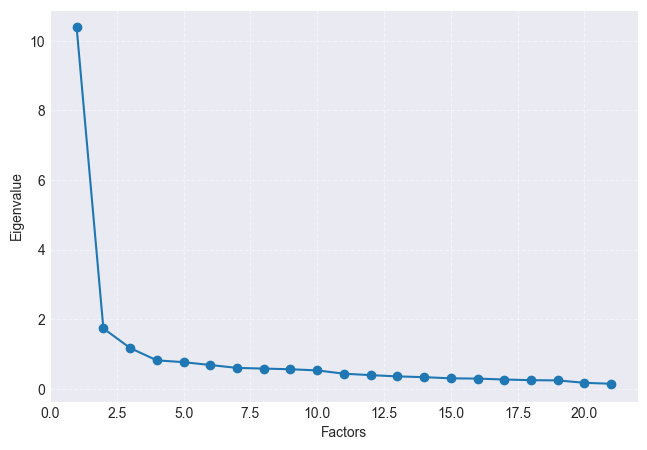

In [59]:
fa = FactorAnalyzer()
fa.fit(imp_dass_data)
# Check Eigenvalues
ev, v = fa.get_eigenvalues()
# Plot Eigenvalues
_define_plot_style(title='', xlabel='Factors', ylabel='Eigenvalue', figsize=(6, 4))
plt.scatter(range(1, imp_dass_data.shape[1] + 1), ev)
plt.plot(range(1, imp_dass_data.shape[1] + 1), ev)
save_and_display_plot('../figures/efa/scree_plot.pdf')
#plt.title('Scree Plot')
#plt.xlabel('Factors')
#plt.ylabel('Eigenvalue')
#plt.grid()
#plt.show()


In [54]:
# Print the eigenvalues
# eigenvalues > 1 indicate the number of factors to retain (kaiser criterion)
for i, val in enumerate(ev, 1):
    print(f"Factor {i}: Eigenvalue = {val:.3f}")

Factor 1: Eigenvalue = 10.383
Factor 2: Eigenvalue = 1.735
Factor 3: Eigenvalue = 1.171
Factor 4: Eigenvalue = 0.816
Factor 5: Eigenvalue = 0.765
Factor 6: Eigenvalue = 0.683
Factor 7: Eigenvalue = 0.600
Factor 8: Eigenvalue = 0.580
Factor 9: Eigenvalue = 0.561
Factor 10: Eigenvalue = 0.528
Factor 11: Eigenvalue = 0.434
Factor 12: Eigenvalue = 0.392
Factor 13: Eigenvalue = 0.356
Factor 14: Eigenvalue = 0.333
Factor 15: Eigenvalue = 0.300
Factor 16: Eigenvalue = 0.292
Factor 17: Eigenvalue = 0.266
Factor 18: Eigenvalue = 0.247
Factor 19: Eigenvalue = 0.241
Factor 20: Eigenvalue = 0.172
Factor 21: Eigenvalue = 0.144


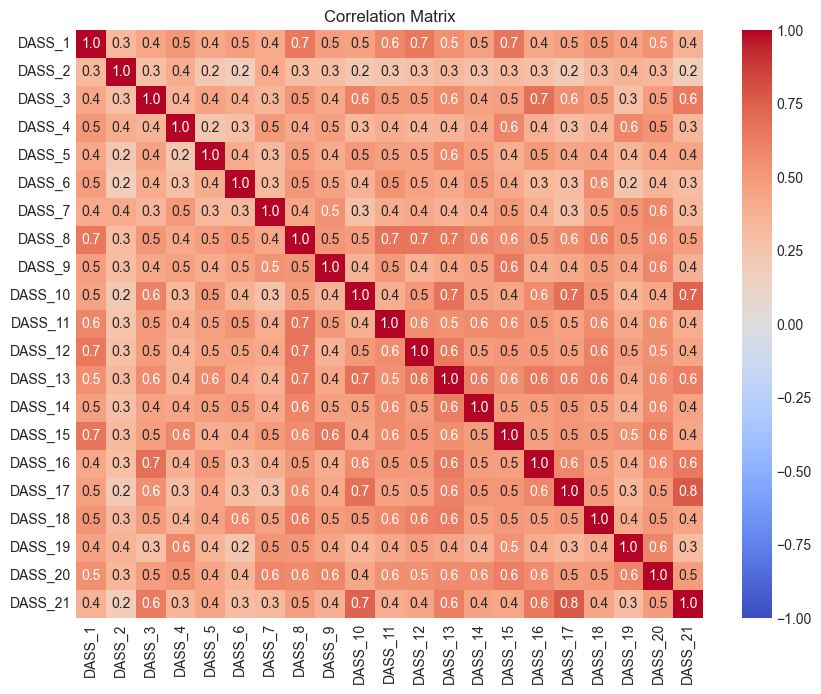

         DASS_1  DASS_2  DASS_3  DASS_4  DASS_5  DASS_6  DASS_7  DASS_8  \
DASS_1     1.00    0.33    0.43    0.50    0.43    0.48    0.41    0.65   
DASS_2     0.33    1.00    0.28    0.40    0.23    0.19    0.41    0.31   
DASS_3     0.43    0.28    1.00    0.35    0.45    0.40    0.35    0.51   
DASS_4     0.50    0.40    0.35    1.00    0.24    0.28    0.50    0.42   
DASS_5     0.43    0.23    0.45    0.24    1.00    0.41    0.32    0.48   
DASS_6     0.48    0.19    0.40    0.28    0.41    1.00    0.33    0.52   
DASS_7     0.41    0.41    0.35    0.50    0.32    0.33    1.00    0.43   
DASS_8     0.65    0.31    0.51    0.42    0.48    0.52    0.43    1.00   
DASS_9     0.47    0.30    0.42    0.47    0.40    0.46    0.53    0.52   
DASS_10    0.46    0.22    0.61    0.33    0.50    0.37    0.27    0.48   
DASS_11    0.59    0.25    0.49    0.39    0.47    0.53    0.39    0.67   
DASS_12    0.66    0.28    0.49    0.36    0.46    0.46    0.42    0.66   
DASS_13    0.54    0.33  

In [55]:
# Correlation Matrix

# Compute correlation matrix
corr_matrix = imp_dass_data.corr()

# Plot heatmap
_define_plot_style(title='Correlation Matrix', figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap='coolwarm', vmin=-1, vmax=1)
save_and_display_plot('../figures/efa/corr_matrix.pdf')

print(corr_matrix.round(2))

# all r> 0.3


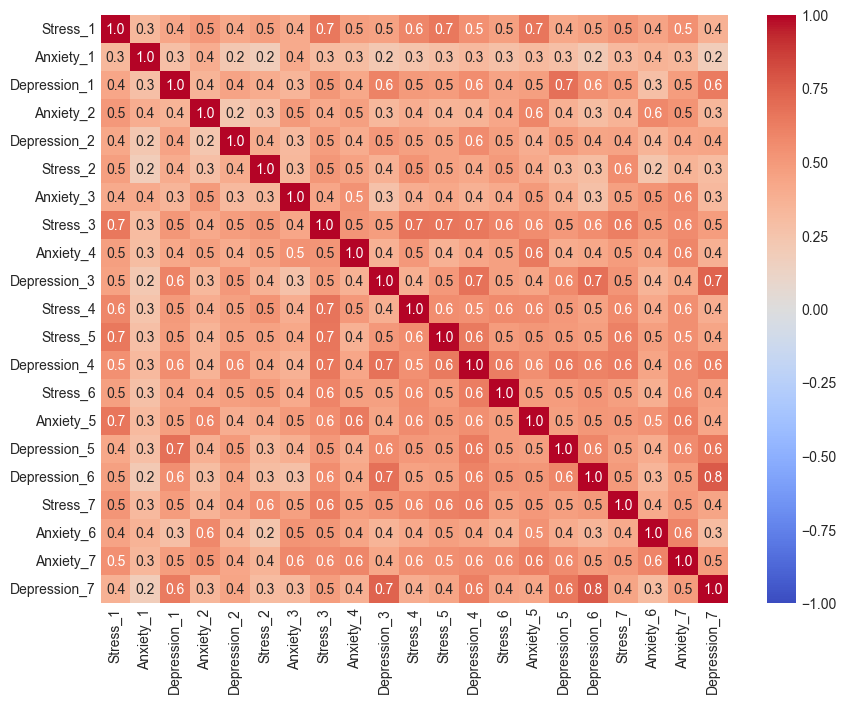

              Stress_1  Anxiety_1  Depression_1  Anxiety_2  Depression_2  \
Stress_1          1.00       0.33          0.43       0.50          0.43   
Anxiety_1         0.33       1.00          0.28       0.40          0.23   
Depression_1      0.43       0.28          1.00       0.35          0.45   
Anxiety_2         0.50       0.40          0.35       1.00          0.24   
Depression_2      0.43       0.23          0.45       0.24          1.00   
Stress_2          0.48       0.19          0.40       0.28          0.41   
Anxiety_3         0.41       0.41          0.35       0.50          0.32   
Stress_3          0.65       0.31          0.51       0.42          0.48   
Anxiety_4         0.47       0.30          0.42       0.47          0.40   
Depression_3      0.46       0.22          0.61       0.33          0.50   
Stress_4          0.59       0.25          0.49       0.39          0.47   
Stress_5          0.66       0.28          0.49       0.36          0.46   
Depression_4

In [58]:
# rename matrix to better understand the correlations between common factors
rename_mapping = {
    'DASS_1': 'Stress_1',
    'DASS_2': 'Anxiety_1',
    'DASS_3': 'Depression_1',
    'DASS_4': 'Anxiety_2',
    'DASS_5': 'Depression_2',
    'DASS_6': 'Stress_2',
    'DASS_7': 'Anxiety_3',
    'DASS_8': 'Stress_3',
    'DASS_9': 'Anxiety_4',
    'DASS_10': 'Depression_3',
    'DASS_11': 'Stress_4',
    'DASS_12': 'Stress_5',
    'DASS_13': 'Depression_4',
    'DASS_14': 'Stress_6',
    'DASS_15': 'Anxiety_5',
    'DASS_16': 'Depression_5',
    'DASS_17': 'Depression_6',
    'DASS_18': 'Stress_7',
    'DASS_19': 'Anxiety_6',
    'DASS_20': 'Anxiety_7',
    'DASS_21': 'Depression_7'
}

corr_matrix_renamed = corr_matrix.rename(columns=rename_mapping, index=rename_mapping)

# Plot heatmap
_define_plot_style(title='', figsize=(8, 6))
sns.heatmap(corr_matrix_renamed, annot=True, fmt=".1f", cmap='coolwarm', vmin=-1, vmax=1)
save_and_display_plot('../figures/efa/corr_matrix.pdf')



print(corr_matrix_renamed.round(2))


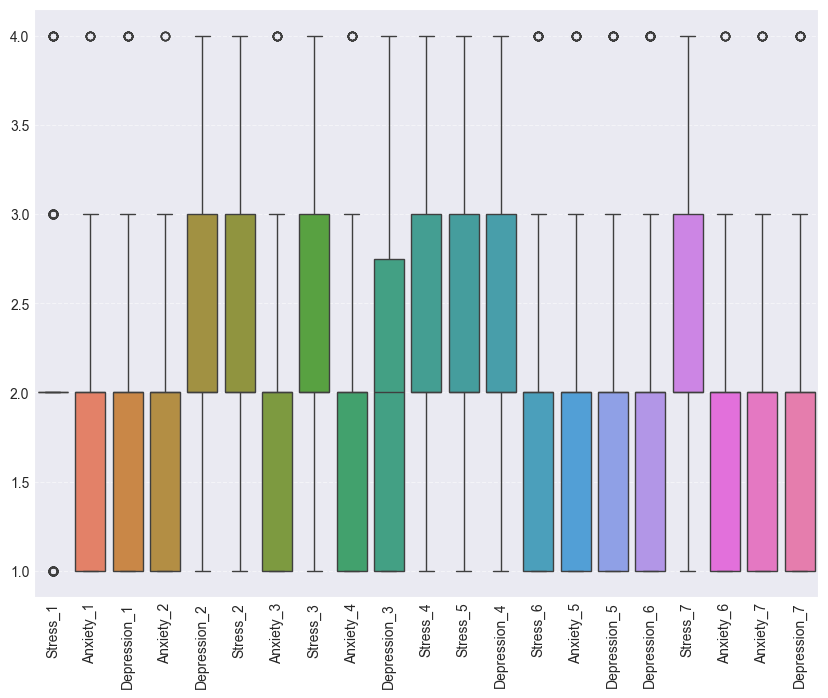

In [60]:
# check outliers
imp_dass_data_renamed = imp_dass_data.rename(columns=rename_mapping)

_define_plot_style(figsize=(8, 6))
sns.boxplot(data=imp_dass_data_renamed)
plt.xticks(rotation=90)
save_and_display_plot('../figures/efa/boxplot.pdf')


/var/folders/vc/w224g4g51l30j_08m3tc0pd80000gn/T/ipykernel_15186/1496785214.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(),rotation=90)
/var/folders/vc/w224g4g51l30j_08m3tc0pd80000gn/T/ipykernel_15186/1496785214.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(),rotation=90)
/var/folders/vc/w224g4g51l30j_08m3tc0pd80000gn/T/ipykernel_15186/1496785214.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(),rotation=90)


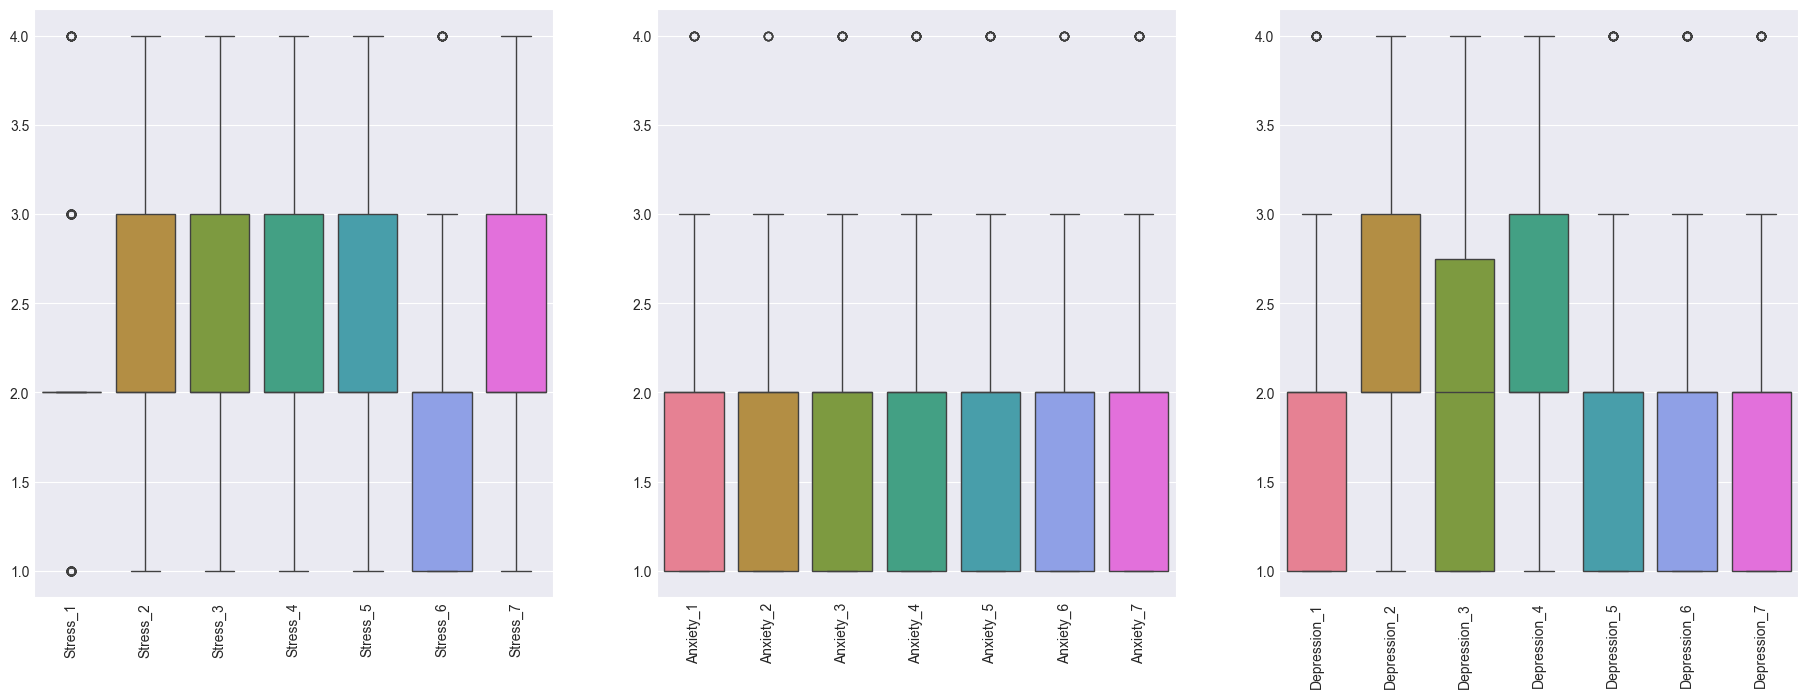

In [64]:
# group boxplots by factor

stress_filter = [col for col in imp_dass_data_renamed if col.startswith('Stress_')]
anxiety_filter = [col for col in imp_dass_data_renamed if col.startswith('Anxiety_')]
depression_filter = [col for col in imp_dass_data_renamed if col.startswith('Depression_')]
stress_data = imp_dass_data_renamed[stress_filter]
anxiety_data = imp_dass_data_renamed[anxiety_filter]
depression_data = imp_dass_data_renamed[depression_filter]


fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(18, 6))
sns.boxplot(data=stress_data, ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(),rotation=90)
sns.boxplot(data=anxiety_data, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(),rotation=90)
sns.boxplot(data=depression_data, ax=axes[2])
axes[3].set_xticklabels(axes[3].get_xticklabels(),rotation=90)
plt.xticks(rotation=90)
save_and_display_plot('../figures/efa/boxplot_by_category.pdf')



In [66]:
# lets get the communalities to see how much variance is explained by the factors and how many responses are needed
# Run EFA with the expected number of factors (3 for DASS-21)
# Calculating communalities with varimax rotation (assuming independent factors)

fa_varimax = FactorAnalyzer(n_factors=3, rotation='varimax')
fa_varimax.fit(imp_dass_data_renamed)

# Get communalities
communalities_varimax = fa_varimax.get_communalities()
communalities_df_varimax = pd.DataFrame({
    'Item': imp_dass_data_renamed.columns,
    'Communality': communalities_varimax
})

print(communalities_df_varimax)

# Communality
communality_varimax = Series(communalities_varimax, index=imp_dass_data_renamed.columns)
#communality_varimax.plot(
#    kind="bar",
#    ylabel="communality"
#)


            Item  Communality
0       Stress_1     0.578653
1      Anxiety_1     0.239323
2   Depression_1     0.554073
3      Anxiety_2     0.569594
4   Depression_2     0.409084
5       Stress_2     0.472612
6      Anxiety_3     0.512475
7       Stress_3     0.687314
8      Anxiety_4     0.493799
9   Depression_3     0.680729
10      Stress_4     0.607913
11      Stress_5     0.581037
12  Depression_4     0.691136
13      Stress_6     0.503908
14     Anxiety_5     0.621371
15  Depression_5     0.604831
16  Depression_6     0.662903
17      Stress_7     0.579713
18     Anxiety_6     0.539108
19     Anxiety_7     0.654382
20  Depression_7     0.824103


/Users/ricardo.ferreira/.pyenv/versions/forms/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [67]:
# Calculating communalities with oblimin rotation (assuming correlation between factors)

fa_oblimin = FactorAnalyzer(n_factors=3, rotation='oblimin')
fa_oblimin.fit(imp_dass_data_renamed)

# Get communalities
communalities_oblimin = fa_oblimin.get_communalities()
communalities_df_oblimin= pd.DataFrame({
    'Item': imp_dass_data_renamed.columns,
    'Communality': communalities_oblimin
})

print(communalities_df_oblimin)


# Communality
communality_oblimin = Series(communalities_oblimin, index=imp_dass_data_renamed.columns)
# communality_oblimin.plot(
#     kind="bar",
#     ylabel="communality"
# )



            Item  Communality
0       Stress_1     0.393338
1      Anxiety_1     0.226796
2   Depression_1     0.370783
3      Anxiety_2     0.685843
4   Depression_2     0.261666
5       Stress_2     0.638044
6      Anxiety_3     0.502573
7       Stress_3     0.507966
8      Anxiety_4     0.305156
9   Depression_3     0.612754
10      Stress_4     0.518960
11      Stress_5     0.414238
12  Depression_4     0.410227
13      Stress_6     0.267811
14     Anxiety_5     0.370327
15  Depression_5     0.421097
16  Depression_6     0.561121
17      Stress_7     0.431237
18     Anxiety_6     0.532415
19     Anxiety_7     0.424666
20  Depression_7     0.970442


/Users/ricardo.ferreira/.pyenv/versions/forms/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


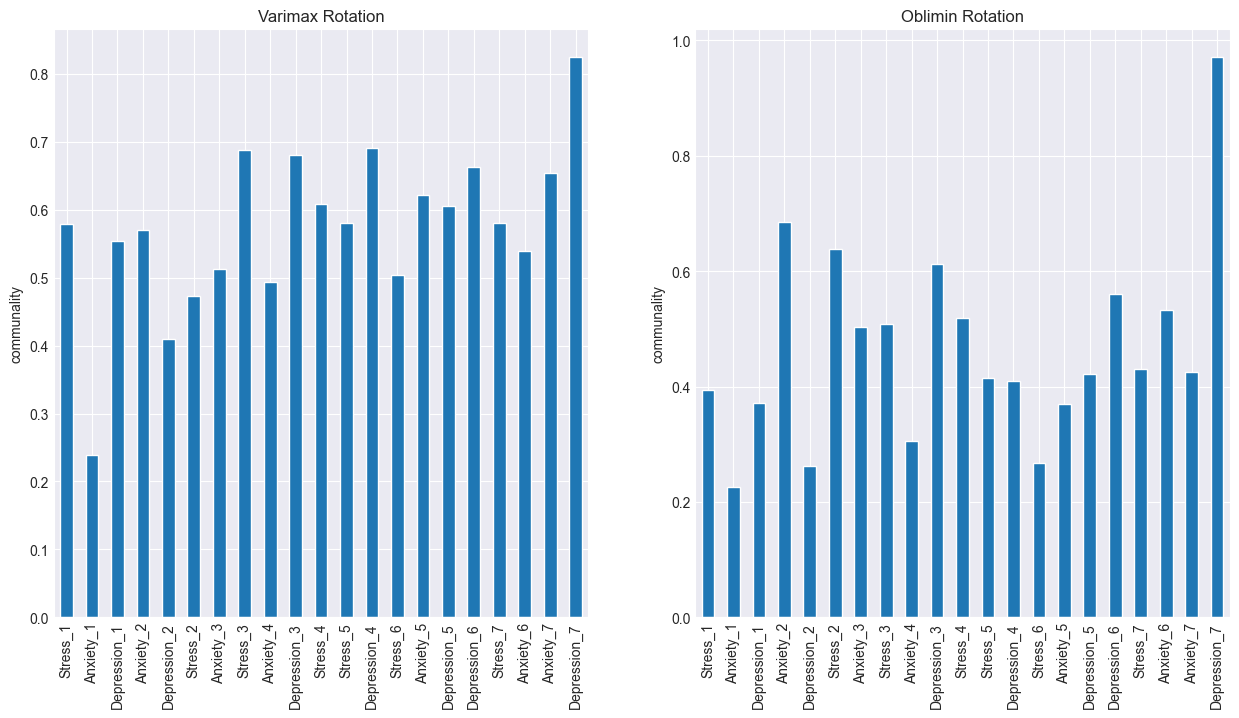

In [68]:
# Display both graphs

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(12, 6))
communality_varimax.plot(kind="bar", ylabel="communality", ax=axes[0])
axes[0].set_title('Varimax Rotation')
communality_oblimin.plot(kind="bar", ylabel="communality", ax=axes[1])
axes[1].set_title('Oblimin Rotation')
save_and_display_plot('../figures/efa/communalities.pdf')


In [72]:
loadings_varimax = fa_varimax.loadings_
loadings_df_varimax = pd.DataFrame(loadings_varimax, index=imp_dass_data_renamed.columns, columns=['Factor1', 'Factor2', 'Factor3'])

# Display the loadings for DASS items
print(loadings_df_varimax)


               Factor1   Factor2   Factor3
Stress_1      0.242469  0.567488  0.444768
Anxiety_1     0.126402  0.159911  0.444718
Depression_1  0.618694  0.330298  0.249388
Anxiety_2     0.174695  0.154512  0.717776
Depression_2  0.414807  0.438865  0.210753
Stress_2      0.174619  0.638849  0.184367
Anxiety_3     0.142737  0.248932  0.655846
Stress_3      0.340972  0.660603  0.366955
Anxiety_4     0.229341  0.379475  0.545161
Depression_3  0.751473  0.295741  0.168980
Stress_4      0.263034  0.647554  0.345541
Stress_5      0.346416  0.598660  0.320374
Depression_4  0.589560  0.512337  0.284720
Stress_6      0.370517  0.492239  0.352599
Anxiety_5     0.293042  0.399987  0.612787
Depression_5  0.649640  0.273429  0.328687
Depression_6  0.732527  0.285166  0.212105
Stress_7      0.338715  0.606397  0.311878
Anxiety_6     0.185243  0.225658  0.673700
Anxiety_7     0.353963  0.328681  0.648892
Depression_7  0.874103  0.142871  0.199085


In [73]:
loadings_oblimin = fa_oblimin.loadings_
loadings_df_oblimin = pd.DataFrame(loadings_oblimin, index=imp_dass_data_renamed.columns, columns=['Factor1', 'Factor2', 'Factor3'])

# Display the loadings for DASS items
print(loadings_df_oblimin)



               Factor1   Factor2   Factor3
Stress_1      0.567044 -0.020102  0.267198
Anxiety_1     0.019192  0.000291  0.475844
Depression_1  0.188780  0.576424  0.053674
Anxiety_2    -0.108317  0.005869  0.821021
Depression_2  0.420840  0.290691 -0.007624
Stress_2      0.789983 -0.078630 -0.088256
Anxiety_3     0.060303 -0.058415  0.703935
Stress_3      0.700326  0.079517  0.105765
Anxiety_4     0.263398  0.018368  0.485221
Depression_3  0.130011  0.769657 -0.058982
Stress_4      0.713553 -0.006553  0.098790
Stress_5      0.627992  0.120477  0.073144
Depression_4  0.444445  0.460703  0.021170
Stress_6      0.456023  0.185988  0.158942
Anxiety_5     0.247376  0.074528  0.550978
Depression_5  0.067500  0.620909  0.176104
Depression_6  0.104026  0.741805  0.004980
Stress_7      0.644669  0.109670  0.060096
Anxiety_6     0.007235 -0.000594  0.729632
Anxiety_7     0.112978  0.170411  0.618758
Depression_7 -0.137489  0.975097  0.026896


In [84]:
# Compute Cronbach's alpha for each factor

stress_alfa_result = pg.cronbach_alpha(stress_data)
anxiety_alfa_result = pg.cronbach_alpha(anxiety_data)
depression_alfa_result = pg.cronbach_alpha(depression_data)

print(f'Cronbach\'s alpha for Stress: {stress_alfa_result[0]:.2f} and confidence interval: {stress_alfa_result[1]}')
print(f'Cronbach\'s alpha for Anxiety: {anxiety_alfa_result[0]:.2f} and confidence interval: {anxiety_alfa_result[1]}')
print(f'Cronbach\'s alpha for Depression: {depression_alfa_result[0]:.2f} and confidence interval: {depression_alfa_result[1]}')

Cronbach's alpha for Stress: 0.90 and confidence interval: [0.877 0.917]
Cronbach's alpha for Anxiety: 0.87 and confidence interval: [0.846 0.897]
Cronbach's alpha for Depression: 0.91 and confidence interval: [0.892 0.928]


In [85]:
# Cronbach's alpha removing Anxiety_1 (DASS_2)

anxiety_data_no_anxiety_1 = anxiety_data.drop(columns=['Anxiety_1'])
anxiety_alfa_result_no_anxiety_1 = pg.cronbach_alpha(anxiety_data_no_anxiety_1)
print(f'Cronbach\'s alpha for Anxiety without Anxiety_1: {anxiety_alfa_result_no_anxiety_1[0]:.2f} and confidence interval: {anxiety_alfa_result_no_anxiety_1[1]}')

Cronbach's alpha for Anxiety without Anxiety_1: 0.88 and confidence interval: [0.853 0.902]
